In [1]:
# 유방암 예측 모델
'''
문6-1> 데이터셋을 불러오고, 아래 항목을 확인하시오.
- 데이터의 행과 열의 구조(shape)
- 'label'의 유형과 각 유형별 데이터의 개수
- 결측치, 중복값 존재 여부
'''
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [4]:
breast_cancer = load_breast_cancer()
type(breast_cancer)
breast_cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [5]:
df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['label'] = breast_cancer.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [ ]:
# 데이터의 행과 열의 구조
print(df.shape)
# 결과: 유방암 데이터는 총 569개의 행과 열(30개 속성, 종속변수 1개)로 구성되어 있다.

(569, 31)


In [ ]:
# label의 유형과 각 유형별 데이터의 개수
print(df['label'].value_counts())
# 결과: 악성(0)은 212, 양성(1)은 357

label
1    357
0    212
Name: count, dtype: int64


In [9]:

# 결측치 확인
null_count = df.isnull().sum().sum()
# 중복값 확인
duplicated_count = df.duplicated().sum()

print('결측치 개수:{}, 중복값 개수:{}'.format(null_count, duplicated_count))

결측치 개수:0, 중복값 개수:0


In [10]:
'''
문6-2> 'label'열을 제외한 나머지 컬럼을 독립변수(X)로 지정하고, 'label'열은 종속변수(y)로 지정한다. 독립변수에 해당하는 열은 평균 0, 표준편차 1이 되도록 데이터를 변환하시오.
'''
# 독립변수와 종속변수의 분할
X = df.drop(['label'], axis=1)
y = df['label']

# 표준화: 스케일 변환 -> 평균 0, 표준편차 1
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)
scaled_X

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]], shape=(569, 30))

In [12]:
'''
문6-3> 학습용 데이터와 테스트용 데이터를 분할하시오.
'''
# 학습용 데이터와 테스트용 데이터의 분할
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, stratify=y,  random_state=42)

print(X_train.shape, X_test.shape)

(426, 30) (143, 30)


In [13]:
'''
문6-4> 다음의 모델을 생성하여 학습을 수행하고, 테스트셋을 사용하여 각 모델 별 정확도를 소수점 넷째자리까지 출력하시오.
- 생성 모델: Decision Tree, KNN, SVM, Random Forest, Logistic Regressor
- Random Forest의 n_estimator=300으로 설정
'''
# 모델 인스턴스 생성
tree_model = DecisionTreeClassifier(random_state=42)
neighbor_model = KNeighborsClassifier(n_neighbors=5)
svm_model = SVC(random_state=42)
forest_model = RandomForestClassifier(n_estimators=300, random_state=42)
logistic_model = LogisticRegression(random_state=42)

model_list = [tree_model, neighbor_model, svm_model, forest_model, logistic_model]

# 모델의 학습 및 정확도 출력
for model in model_list:
    model.fit(X_train, y_train)
    # 평가
    score = model.score(X_test, y_test)
    model_name = model.__class__.__name__
    print('{0} 정확도: {1:.4f}'.format(model_name, score))

DecisionTreeClassifier 정확도: 0.9231
KNeighborsClassifier 정확도: 0.9720
SVC 정확도: 0.9790
RandomForestClassifier 정확도: 0.9580
LogisticRegression 정확도: 0.9860


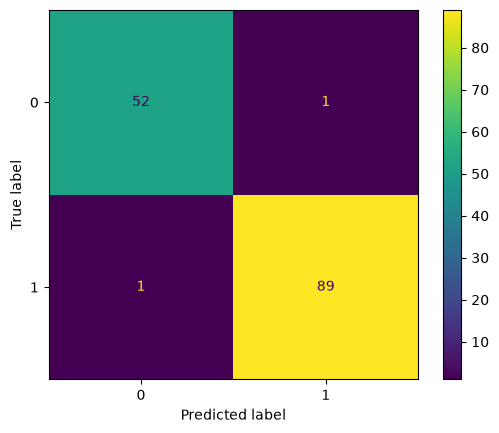

In [14]:
'''
문6-5> 문6-4에서 생성한 LogisticRegression 모델을 사용하여 혼동 행렬을 생성하고, 오분류 데이터의 개수를 확인하시오.
'''
# 예측
y_pred = logistic_model.predict(X_test)

# 혼동 행렬 생성
cm = confusion_matrix(y_test, y_pred)

# 혼동 행렬 시각화
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [16]:
'''
문6-6> 문6-4에서 생성한 LogisticRegression 모델을 사용하여 분류 모델의 평가 지표(정확도, 정밀도, 재현율, f1-score)를 소수점 넷째자리까지 출력하시오. 유방암 예측 모델의 경우, 위의 4가지 지표 중 가장 중요도가 높은 평가 지표가 무엇인지 설명하시오.
'''
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('정확도: {:.4f}, 정밀도: {:.4f}, 재현율: {:.4f}, F1-score: {:.4f}'.format(accuracy, precision, recall, f1))


정확도: 0.9860, 정밀도: 0.9889, 재현율: 0.9889, F1-score: 0.9889


In [ ]:
'''
정확도: 0.9860, 정밀도: 0.9889, 재현율: 0.9889, F1-score: 0.9889

재현율(또는 민감도, Sensitivity)은 실제 암 환자 중 모델이 정확히 암을 예측한 비율이다. 유방암 예측에서 재현율은 매우 중요한 이유는, 유방암 환자를 놓치는 경우는 매우 위험하기 때문이다. 만약 모델이 암 환자를 놓치는 경우(False Negative)가 많다면, 환자들은 적절한 진료를 받지 못할 수 있다. 따라서 재현율이 높다는 것은 암 환자를 놓치지 않는 모델을 의미하므로 재현율을 평가 지표로 사용하는 것이 바람직하다.
'''

In [17]:
'''
문6-7> 문6-4에서 생성한 Random Forest 모델의 GridSearchCV를 사용하여 하이퍼파라미터 튜닝을 수행하고자 한다. 주어진 조건을 사용하여 재현율이 가장 높은 최적 조건을 구하고, 그때의 테스트셋의 재현율을 확인하시오.
'''
params = {
    'n_estimators': [10, 100, 300],
    'max_depth': [2, 4, 6]
}

grid_cv = GridSearchCV(forest_model, param_grid=params, cv=3)
grid_cv.fit(X_train, y_train)

print('최적 조건:', grid_cv.best_params_)

model = grid_cv.best_estimator_
y_pred = model.predict(X_test)

print('테스트셋 재현율:{:.4f}'.format(recall_score(y_test, y_pred)))

최적 조건: {'max_depth': 6, 'n_estimators': 100}
테스트셋 재현율:0.9667


In [ ]:
'''
최적 조건: {'max_depth': 6, 'n_estimators': 100}
테스트셋 재현율:0.9667
'''

In [20]:
'''
문6-8> 문6-7에서 확인한 최적의 Random Forest 모델을 사용하여 주어진 데이터셋을 학습시키고, 예측 결과에 가장 중요한 변수 5개를 확인하시오.
'''
rf_feature_importances = pd.Series(data=model.feature_importances_, index=X.columns)
print(rf_feature_importances.sort_values(ascending=False)[:5])

worst area              0.152309
worst concave points    0.127365
mean concave points     0.103126
worst radius            0.085575
worst perimeter         0.083333
dtype: float64


In [ ]:
'''
worst area              0.152309
worst concave points    0.127365
mean concave points     0.103126
worst radius            0.085575
worst perimeter         0.083333
dtype: float64
'''